# 🌊 Physics & Sensitometry: Spectral Response and Optical Filters

### Welcome, Optical Physicists!
In traditional black and white photography, a common misconception is that colored glass filters (placed over the camera lens) are "contrast filters." 

Generally speaking, optical filters do not change the *overall* contrast of a negative—overall contrast is controlled by the chemical development time. Instead, filters change the *local* contrast (the tonal relationships between specific colored objects). For example, a red filter blocks cyan (blue/green) light, rendering a blue sky almost black, which makes white clouds pop out dramatically.

However, photographic theory and reality sometimes collide. In this module, we will examine a strange anomaly where an extreme red filter actually *lowered* the contrast of an image, and we will use physics to understand why.

## Step 1: The Red Filter Anomaly
Conventional photographic theory dictates that using a strong red filter on a landscape should result in a highly dramatic, punchy negative. 

When testing a B+W #091 Red filter, however, the results were surprisingly flat. The resulting negatives produced very low-contrast prints with wide-open shadows and skies that were not nearly as dark as expected. 

To understand why this happened, we cannot just look at a color wheel. We must look at the exact physics of light wavelengths (measured in nanometers, nm) and examine two critical pieces of data:
1. **The Filter Transmission Curve:** Exactly which wavelengths of light does the glass allow to pass through?
2. **The Film Sensitivity Curve:** Exactly which wavelengths of light is the silver halide emulsion actually sensitive to?

## Step 2: Superimposing the Physics (Figures 48 & 49)

Let's look at the B+W #091 Red filter. It has an incredibly sharp cutoff. It literally stops almost all visible light, only letting through deep red wavelengths starting around 600nm. 

Now, let's look at a standard panchromatic film, like Ilford HP5 Plus. While it is sensitive to "all" colors, its sensitivity drops off like a cliff right as the light hits the deep red spectrum (around 640nm). 

Let's use Python to graph these two curves on top of each other to find the "window of exposure."

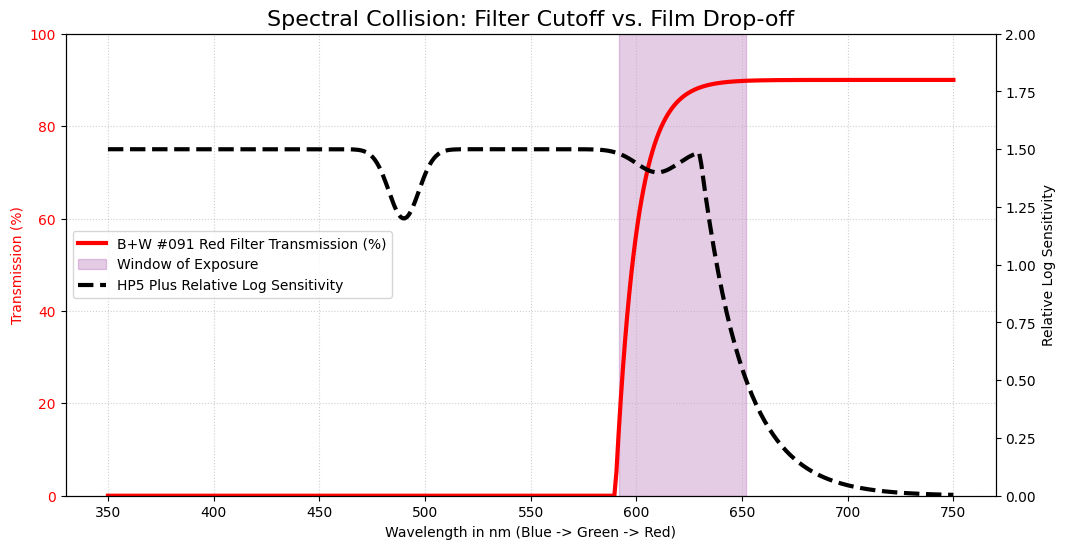

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_spectral_collision():
    """
    Recreates Figures 48 and 49:
    Superimposing the transmission curve of a B+W #091 Red Filter
    over the spectral sensitivity curve of Ilford HP5 Plus film.
    """
    # Wavelengths of visible light in nanometers (nm)
    wavelengths = np.linspace(350, 750, 400)
    
    # 1. B+W #091 Red Filter Transmission Curve
    # Blocks almost everything until ~590nm, then shoots up to ~90% transmission
    filter_transmission = np.zeros_like(wavelengths)
    filter_transmission[wavelengths > 590] = 90 * (1 - np.exp(-0.1 * (wavelengths[wavelengths > 590] - 590)))
    
    # 2. Ilford HP5 Plus Spectral Sensitivity Curve
    # Highly sensitive in the blue/green (400-550nm), dips slightly, peaks again around 600nm,
    # then drops like a rock at 640nm.
    film_sensitivity = np.ones_like(wavelengths) * 1.5 # Baseline log sensitivity
    
    # Simulate the blue/green dip and red peak
    film_sensitivity -= 0.3 * np.exp(-0.01 * (wavelengths - 490)**2)
    film_sensitivity -= 0.1 * np.exp(-0.005 * (wavelengths - 610)**2)
    
    # Simulate the massive drop-off in red sensitivity after 630nm
    film_sensitivity[wavelengths > 630] -= 1.5 * (1 - np.exp(-0.05 * (wavelengths[wavelengths > 630] - 630)))
    film_sensitivity = np.clip(film_sensitivity, 0, 2.0) # Keep within bounds

    # 3. Plotting the collision
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Filter Transmission on the primary Y-axis (left)
    ax1.plot(wavelengths, filter_transmission, 'r-', lw=3, label="B+W #091 Red Filter Transmission (%)")
    ax1.set_xlabel("Wavelength in nm (Blue -> Green -> Red)")
    ax1.set_ylabel("Transmission (%)", color='red')
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.set_ylim(0, 100)

    # Plot Film Sensitivity on the secondary Y-axis (right)
    ax2 = ax1.twinx()
    ax2.plot(wavelengths, film_sensitivity, 'k--', lw=3, label="HP5 Plus Relative Log Sensitivity")
    ax2.set_ylabel("Relative Log Sensitivity", color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.set_ylim(0, 2.0)
    
    # Highlight the "Window of Exposure"
    overlap_condition = (filter_transmission > 10) & (film_sensitivity > 0.5)
    ax1.fill_between(wavelengths, 0, 100, where=overlap_condition, color='purple', alpha=0.2, label="Window of Exposure")

    # Formatting
    plt.title("Spectral Collision: Filter Cutoff vs. Film Drop-off", fontsize=16)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')

    plt.show()

# Run the spectral simulation!
simulate_spectral_collision()

### 🔬 Analysis: The Window of Exposure

Look closely at the purple shaded area in the graph above. This represents the only light that successfully passes through the lens *and* is recorded by the film. 

* The filter blocks everything below 600nm.
* The film goes completely blind to everything above 650nm.

**The Conclusion:**
There is barely any light reaching the film that the film can actually "see." Because the film is starved of the wavelengths it relies on to build dense highlights, the overall density of the negative remains thin. This narrow spectral window acts as an extreme equalizer, crushing the contrast of the resulting image. 

Understanding this optical physics allows you to intentionally use a harsh red filter to tame an uncontrollably high-contrast scene!

## Step 1.5: Analyzing Multiple Transmission Curves (Figure 48)

Before we see how a filter interacts with film, we must understand the filters themselves. B+W Filter Transmission Chart A (Figure 48 in the text) shows how different colored glass filters transmit or block specific wavelengths of light.

* **Blue Filters (e.g., #081):** Allow short wavelengths to pass, blocking reds.
* **Green Filters (e.g., #060, #061):** Act as a "band-pass," allowing the middle wavelengths to pass while blocking extreme blues and reds.
* **Red Filters (e.g., #090, #091):** Act as a "high-pass" or edge filter, blocking short and medium wavelengths and only allowing the longest visible wavelengths to pass.

Let's generate the complete transmission chart to see these curves side-by-side.

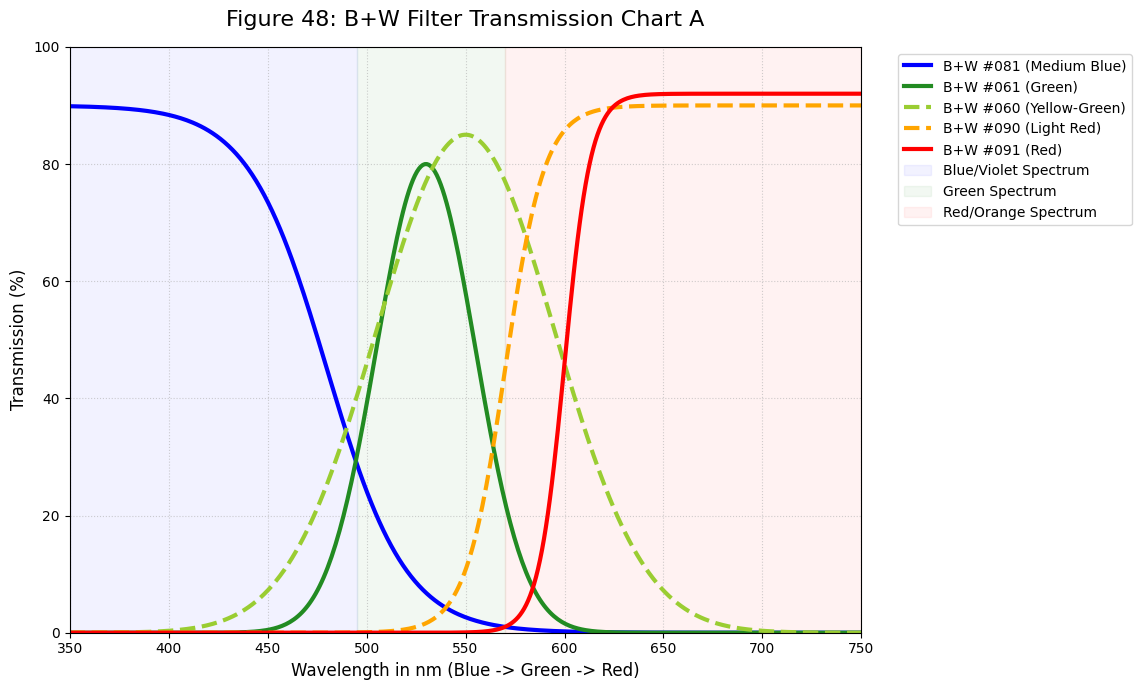

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_bw_transmission_chart():
    """
    Recreates Figure 48: B+W Filter Transmission Chart A.
    Simulates the transmission curves for Blue, Green, and Red filters.
    """
    # Wavelengths of visible light in nanometers (nm)
    # 350nm (UV/Blue) to 750nm (Deep Red/IR)
    wavelengths = np.linspace(350, 750, 400)
    
    # --- BLUE FILTERS ---
    # #081 (Medium Blue): High transmission in blue, drops off through green and red
    filter_081 = 90 * (1 - 1 / (1 + np.exp(-0.05 * (wavelengths - 480))))
    
    # --- GREEN FILTERS ---
    # #061 (Green): A narrow band-pass peaking in the green spectrum (~530nm)
    filter_061 = 80 * np.exp(-0.5 * ((wavelengths - 530) / 25)**2)
    
    # #060 (Yellow-Green): A broader band-pass peaking slightly warmer (~550nm)
    filter_060 = 85 * np.exp(-0.5 * ((wavelengths - 550) / 45)**2)
    
    # --- RED FILTERS ---
    # #090 (Light Red): Sharp cutoff, but allows some yellow/orange through (~560nm)
    filter_090 = 90 / (1 + np.exp(-0.1 * (wavelengths - 570)))
    
    # #091 (Red): Very sharp cutoff, blocking almost everything until deep red (~600nm)
    filter_091 = 92 / (1 + np.exp(-0.15 * (wavelengths - 600)))
    
    # Plotting the Transmission Chart
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ax.plot(wavelengths, filter_081, color='blue', lw=3, label="B+W #081 (Medium Blue)")
    ax.plot(wavelengths, filter_061, color='forestgreen', lw=3, label="B+W #061 (Green)")
    ax.plot(wavelengths, filter_060, color='yellowgreen', lw=3, linestyle='--', label="B+W #060 (Yellow-Green)")
    ax.plot(wavelengths, filter_090, color='orange', lw=3, linestyle='--', label="B+W #090 (Light Red)")
    ax.plot(wavelengths, filter_091, color='red', lw=3, label="B+W #091 (Red)")
    
    # Formatting
    plt.title("Figure 48: B+W Filter Transmission Chart A", fontsize=16, pad=15)
    ax.set_xlabel("Wavelength in nm (Blue -> Green -> Red)", fontsize=12)
    ax.set_ylabel("Transmission (%)", fontsize=12)
    
    ax.set_xlim(350, 750)
    ax.set_ylim(0, 100)
    
    # Add colored background bands for visual reference
    ax.axvspan(350, 495, color='blue', alpha=0.05, label='Blue/Violet Spectrum')
    ax.axvspan(495, 570, color='green', alpha=0.05, label='Green Spectrum')
    ax.axvspan(570, 750, color='red', alpha=0.05, label='Red/Orange Spectrum')
    
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Place legend outside the plot area so it doesn't block the curves
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    
    plt.tight_layout()
    plt.show()

# Run the transmission chart simulator!
simulate_bw_transmission_chart()